# Template — Ingestão de dados via API RIPE Atlas

**Objetivo:** consumir resultados de uma medição pública da API RIPE Atlas, receber os dados em JSON, transformá-los em um `DataFrame` e salvar a coleta no Google Drive.

> Este notebook cobre **somente a ingestão e o armazenamento da camada `raw`**. Não agregue janelas, não crie variáveis, não rotule dados e não treine modelos nesta etapa.

## Entrega mínima

- Justificar as decisões da equipe sobre os parâmetros da consulta;
- Executar uma requisição válida à API;
- Exibir os dados em um `DataFrame`;
- Salvar o JSON original da resposta;
- Salvar os registros em **CSV ou Parquet** na pasta `raw` do Google Drive;
- Registrar evidências da coleta: URL, parâmetros, horário, quantidade de registros e nomes dos arquivos.


## Pipeline da fase de coleta e ingestão

O desenho abaixo apresenta o percurso desta etapa, desde a escolha da medição pública até a verificação dos arquivos salvos na pasta `raw`. Se a consulta não for válida, a equipe deverá revisar os parâmetros e realizar uma nova tentativa.


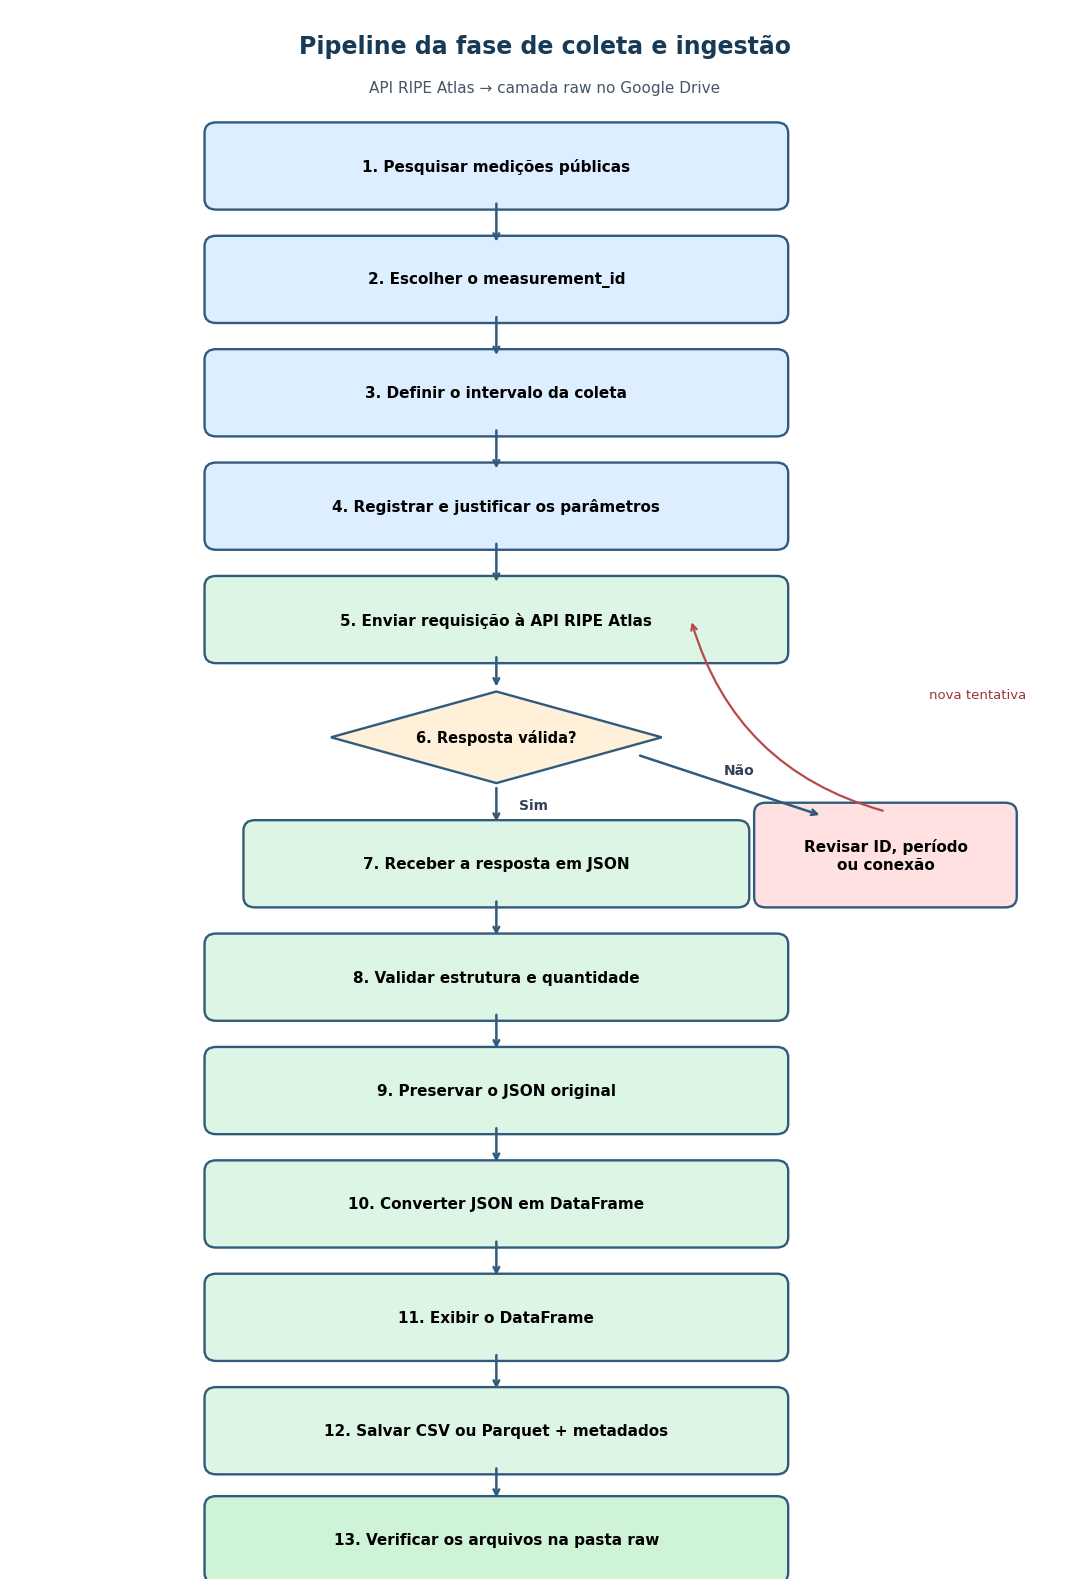

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

# Desenho do pipeline da fase de coleta e ingestão
fig, ax = plt.subplots(figsize=(11, 16))
ax.set_xlim(0, 11)
ax.set_ylim(0, 18)
ax.axis("off")

azul = "#DCEEFF"
verde = "#DDF5E5"
laranja = "#FFF0D9"
vermelho = "#FFE1E1"
borda = "#315A7D"

def caixa(x, y, texto, cor=azul, largura=5.8, altura=0.8):
    forma = FancyBboxPatch(
        (x - largura / 2, y - altura / 2), largura, altura,
        boxstyle="round,pad=0.10,rounding_size=0.12",
        linewidth=1.7, edgecolor=borda, facecolor=cor
    )
    ax.add_patch(forma)
    ax.text(x, y, texto, ha="center", va="center", fontsize=11, weight="bold")

def decisao(x, y, texto):
    largura, altura = 3.4, 1.05
    pontos = [(x, y + altura/2), (x + largura/2, y),
              (x, y - altura/2), (x - largura/2, y)]
    ax.add_patch(Polygon(pontos, closed=True, edgecolor=borda,
                         facecolor=laranja, linewidth=1.7))
    ax.text(x, y, texto, ha="center", va="center", fontsize=10.5, weight="bold")

def seta(x1, y1, x2, y2, rotulo=None, deslocamento=(0, 0)):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.8, color=borda))
    if rotulo:
        ax.text((x1+x2)/2 + deslocamento[0], (y1+y2)/2 + deslocamento[1],
                rotulo, fontsize=10, weight="bold", color="#334155",
                ha="center", va="center")

ax.text(5.5, 17.5, "Pipeline da fase de coleta e ingestão",
        ha="center", fontsize=17, weight="bold", color="#173B57")
ax.text(5.5, 17.05, "API RIPE Atlas → camada raw no Google Drive",
        ha="center", fontsize=11, color="#475569")

etapas = [
    (16.2, "1. Pesquisar medições públicas", azul),
    (14.9, "2. Escolher o measurement_id", azul),
    (13.6, "3. Definir o intervalo da coleta", azul),
    (12.3, "4. Registrar e justificar os parâmetros", azul),
    (11.0, "5. Enviar requisição à API RIPE Atlas", verde),
]
for y, texto, cor in etapas:
    caixa(5, y, texto, cor)

for y1, y2 in [(15.8, 15.3), (14.5, 14.0), (13.2, 12.7), (11.9, 11.4)]:
    seta(5, y1, 5, y2)

decisao(5, 9.65, "6. Resposta válida?")
seta(5, 10.6, 5, 10.2)

# Caminho de erro e nova tentativa
caixa(9.0, 8.3, "Revisar ID, período\nou conexão", vermelho, largura=2.5, altura=1.0)
seta(6.45, 9.45, 8.35, 8.75, "Não", (0.10, 0.18))
ax.annotate("", xy=(7.0, 11.0), xytext=(9.0, 8.8),
            arrowprops=dict(arrowstyle="->", lw=1.6, color="#B84949",
                            connectionstyle="arc3,rad=-0.28"))
ax.text(9.45, 10.1, "nova tentativa", fontsize=9.5, color="#9B3636")

# Caminho principal
caixa(5, 8.2, "7. Receber a resposta em JSON", verde, largura=5.0)
seta(5, 9.1, 5, 8.65, "Sim", (0.38, 0))

caixa(5, 6.9, "8. Validar estrutura e quantidade", verde)
caixa(5, 5.6, "9. Preservar o JSON original", verde)
caixa(5, 4.3, "10. Converter JSON em DataFrame", verde)
caixa(5, 3.0, "11. Exibir o DataFrame", verde)
caixa(5, 1.7, "12. Salvar CSV ou Parquet + metadados", verde)
caixa(5, 0.45, "13. Verificar os arquivos na pasta raw", "#CFF3D7")

for y1, y2 in [(7.8, 7.35), (6.5, 6.05), (5.2, 4.75),
               (3.9, 3.45), (2.6, 2.15), (1.3, 0.9)]:
    seta(5, y1, 5, y2)

plt.tight_layout()
plt.show()


## 1. Identificação da equipe

Preencham antes de executar.

- **Equipe:** ICMP_MASTER

- **Integrantes:**
    - Eduardo Quintino Filho
    - Felipe Veiga da Silva
    - Henrique de Aguiar Fernandes
    - Niccolas Lupetti dos Santos
    - Tharik Lima da Silva

- **RAW_Oficial:** = "ripe_atlas_m2016_20260915T154226Z"

- **Turma:** 4° Ciencia da Computação

- **Data da coleta:** 12/09/2026

- **Data da execução:** 15/09/2026

- **Tempo de coleta:** 1 dia



## 2. Decisões da equipe

Cada equipe deve pesquisar e definir os próprios parâmetros. Registre abaixo:

| Decisão | Escolha da equipe | Justificativa |
|---|---|---|
| ID da medição (`measurement_id`) | 2016 | Escolhemos o measurement_id 2016 por ser uma medição pública do tipo PING, com alvo j.root-servers.net. Verificamos na página da medição no site da RIPE Atlas que ela está ativa (ongoing) e possui histórico de resultados, o que garante retorno de dados na consulta.  |
| Intervalo consultado | Ultima 1 hora antes da execução | Definimos esta janela curta de tempo para garantir volume suficiente de dados porem sem tornar a consulta lenta e ultrapassar os limites da API,garantindo uma consulta eficaz e com dados recentes. |
| Duração do intervalo | 1 Hora  | O período de 1 hora se mostrou adequado após os testes realizados, pois retornou uma quantidade significativa de medições, suficiente para a análise sem aumentar desnecessariamente o volume da coleta. |
| Tipo de medição | PING | O tipo PING foi mantido por ser o tipo nativo da medição 2016 e por fornecer informações relacionadas à latência e ao RTT, que poderão ser utilizadas nas etapas posteriores de análise. |
| Formato de saída: CSV ou Parquet | CSV | Escolhemos CSV por ser o formato alinhado ao contrato de dados do projeto (log_rede.csv), facilitando auditoria e leitura direta por qualquer ferramenta (Excel, pandas, etc.). Parquet exigiria pyarrow e seria menos legível nesta fase de inspeção bruta. |

Antes de escolher, consultem a documentação e verifiquem se a medição é pública, se o ID existe e se o intervalo solicitado possui resultados. Evitem períodos excessivamente longos: eles podem retornar muitos registros ou tornar a consulta lenta.


## 3. Bibliotecas

As bibliotecas abaixo são sugestões para esta etapa. O `pyarrow` é necessário apenas se a equipe escolher Parquet.


In [ ]:
# Execute esta instalação se for usar o formato Parquet.
!pip -q install pyarrow


In [ ]:
import json
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
import requests

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


## 4. Montar o Google Drive e preparar a pasta `raw`

O caminho sugerido cria a pasta `ripe_atlas/raw` dentro de `Meu Drive`. A equipe pode alterar somente a pasta do projeto, mantendo uma subpasta chamada `raw`.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

PASTA_RAW = Path("/content/drive/MyDrive/ripe_atlas/raw")
PASTA_RAW.mkdir(parents=True, exist_ok=True)

print("Arquivos raw serão salvos em:", PASTA_RAW)


Mounted at /content/drive
Arquivos raw serão salvos em: /content/drive/MyDrive/ripe_atlas/raw


## 5. Definir os parâmetros da consulta

Substituam os valores de exemplo pelas decisões da equipe.

- `MEASUREMENT_ID`: identificador numérico de uma medição pública;
- `HORAS_COLETA`: período anterior ao momento da execução;
- `FORMATO_TABELAR`: use `"csv"` ou `"parquet"`;
- `TIMEOUT_REQUISICAO`: tempo máximo de espera, em segundos.

O período usa timestamps Unix em UTC, formato aceito pela API.


In [ ]:
MEASUREMENT_ID = 2016
HORAS_COLETA = 1
FORMATO_TABELAR = "csv"  # opções: "csv" ou "parquet"
TIMEOUT_REQUISICAO = 60

fim_utc = datetime.now(timezone.utc)
inicio_utc = fim_utc - timedelta(hours=HORAS_COLETA)

URL = f"https://atlas.ripe.net/api/v2/measurements/{MEASUREMENT_ID}/results/"
PARAMETROS = {
    "start": int(inicio_utc.timestamp()),
    "stop": int(fim_utc.timestamp()),
}

assert isinstance(MEASUREMENT_ID, int) and MEASUREMENT_ID > 0
assert HORAS_COLETA > 0
assert FORMATO_TABELAR in {"csv", "parquet"}

print("URL:", URL)
print("Início (UTC):", inicio_utc.isoformat())
print("Fim (UTC):", fim_utc.isoformat())
print("Parâmetros:", PARAMETROS)


URL: https://atlas.ripe.net/api/v2/measurements/2016/results/
Início (UTC): 2026-10-08T00:25:13.059183+00:00
Fim (UTC): 2026-10-08T01:25:13.059183+00:00
Parâmetros: {'start': 1791419113, 'stop': 1791422713}


## 6. Consumir a API e obter o JSON

`raise_for_status()` interrompe a execução quando a API devolve um erro HTTP. A resposta bem-sucedida é convertida de JSON para objetos Python com `response.json()`. Válido ressaltar que nesse processo, a equipe não controla as sondas e nem o anycast do j-root.


In [ ]:
instante_requisicao_utc = datetime.now(timezone.utc)

try:
    response = requests.get(
        URL,
        params=PARAMETROS,
        timeout=TIMEOUT_REQUISICAO,
    )
    response.raise_for_status()
    dados_json = response.json()
except requests.exceptions.Timeout as erro:
    raise RuntimeError("A API não respondeu dentro do tempo definido.") from erro
except requests.exceptions.HTTPError as erro:
    raise RuntimeError(
        f"Erro HTTP {response.status_code}. Verifique o ID e os parâmetros."
    ) from erro
except requests.exceptions.RequestException as erro:
    raise RuntimeError(f"Falha de comunicação com a API: {erro}") from erro
except ValueError as erro:
    raise RuntimeError("A resposta recebida não contém JSON válido.") from erro

if not isinstance(dados_json, list):
    raise TypeError("Era esperada uma lista JSON de resultados.")
if len(dados_json) == 0:
    raise ValueError("A consulta não retornou registros. Reveja o ID ou o período.")

print("Status HTTP:", response.status_code)
print("Quantidade de registros recebidos:", len(dados_json))
print("Tipo do objeto principal:", type(dados_json).__name__)


Status HTTP: 200
Quantidade de registros recebidos: 112400
Tipo do objeto principal: list


## 7. Inspecionar uma pequena amostra do JSON

Exiba somente o primeiro registro para compreender a estrutura sem poluir o notebook. A resposta completa será preservada em arquivo.


In [ ]:
print(json.dumps(dados_json[0], indent=2, ensure_ascii=False)[:5000])


{
  "fw": 4790,
  "lts": 41,
  "dst_name": "2001:503:c27::2:30",
  "af": 6,
  "dst_addr": "2001:503:c27::2:30",
  "src_addr": "2a10:3781:e22:1:220:4aff:fec8:23d7",
  "proto": "ICMP",
  "ttl": 246,
  "size": 20,
  "result": [
    {
      "rtt": 31.008775
    },
    {
      "rtt": 30.867462
    },
    {
      "rtt": 30.079494
    }
  ],
  "dup": 0,
  "rcvd": 3,
  "sent": 3,
  "min": 30.079494,
  "max": 31.008775,
  "avg": 30.651910333333333,
  "msm_id": 2016,
  "prb_id": 1,
  "timestamp": 1791419135,
  "msm_name": "Ping",
  "from": "2a10:3781:e22:1:220:4aff:fec8:23d7",
  "type": "ping",
  "step": 240,
  "stored_timestamp": 1791419235
}


## 8. Transformar o JSON em `DataFrame`

`pd.json_normalize()` transforma cada objeto da lista JSON em uma linha e expande campos aninhados quando possível. Nesta etapa, não removam nem agreguem registros.


In [ ]:
df_raw = pd.json_normalize(dados_json, sep="_")

print("Dimensões do DataFrame (linhas, colunas):", df_raw.shape)
display(df_raw.head())

print(df_raw.columns.tolist())

# Validação dos dados raw

print("Registros:", len(df_raw))
print("Colunas:", len(df_raw.columns))

# Verifica campos principais
campos = ["msm_id", "prb_id", "timestamp", "sent", "rcvd", "avg"]

print("\nValores ausentes:")
print(df_raw[campos].isna().sum())

# Verifica identificador da medição
print("\nIDs de medição:", df_raw["msm_id"].unique())

# Verifica registros sem resposta
sem_resposta = df_raw[df_raw["avg"] == -1]

print("\nRegistros com avg = -1:", len(sem_resposta))

display(
    sem_resposta[
        ["msm_id", "prb_id", "timestamp", "sent", "rcvd", "avg"]
    ].head()
)

Dimensões do DataFrame (linhas, colunas): (112400, 25)


,fw,lts,dst_name,af,dst_addr,src_addr,proto,ttl,size,result,...,avg,msm_id,prb_id,timestamp,msm_name,from,type,step,stored_timestamp,mver
0,4790,41,2001:503:c27::2:30,6,2001:503:c27::2:30,2a10:3781:e22:1:220:4aff:fec8:23d7,ICMP,246.0,20,"[{'rtt': 31.008775}, {'rtt': 30.867462}, {'rtt...",...,30.651910,2016,1,1791419135,Ping,2a10:3781:e22:1:220:4aff:fec8:23d7,ping,240,1791419235,NaN
1,4790,511,2001:503:c27::2:30,6,2001:503:c27::2:30,2001:8003:7086:af00:220:4aff:fec7:b000,ICMP,248.0,20,"[{'rtt': 21.39802}, {'rtt': 20.335876}, {'rtt'...",...,21.129988,2016,1000,1791419119,Ping,2001:8003:7086:af00:220:4aff:fec7:b000,ping,240,1791419211,NaN
2,5100,46,2001:503:c27::2:30,6,2001:503:c27::2:30,2603:c020:8015:3900::23,ICMP,60.0,32,"[{'rtt': 1.004773}, {'rtt': 1.087334}, {'rtt':...",...,1.060147,2016,1000017,1791419138,Ping,2603:c020:8015:3900::23,ping,240,1791419213,2.6.4
3,5130,15,2001:503:c27::2:30,6,2001:503:c27::2:30,2a01:4f8:13a:13d5::2001,ICMP,250.0,32,"[{'rtt': 33.567409}, {'rtt': 33.625555}, {'rtt...",...,33.538439,2016,1000021,1791419127,Ping,2a01:4f8:13a:13d5::2001,ping,240,1791419213,2.6.4
4,5080,24,2001:503:c27::2:30,6,2001:503:c27::2:30,2001:1ae9:600f:4100:da58:d7ff:fe00:1dc,ICMP,55.0,32,"[{'rtt': 15.235942}, {'rtt': 15.913092}, {'rtt...",...,15.398489,2016,1000032,1791419136,Ping,2001:1ae9:600f:4100:da58:d7ff:fe00:1dc,ping,240,1791419164,2.6.3


['fw', 'lts', 'dst_name', 'af', 'dst_addr', 'src_addr', 'proto', 'ttl', 'size', 'result', 'dup', 'rcvd', 'sent', 'min', 'max', 'avg', 'msm_id', 'prb_id', 'timestamp', 'msm_name', 'from', 'type', 'step', 'stored_timestamp', 'mver']
Registros: 112400
Colunas: 25

Valores ausentes:
msm_id       0
prb_id       0
timestamp    0
sent         0
rcvd         0
avg          0
dtype: int64

IDs de medição: [2016]

Registros com avg = -1: 11762


,msm_id,prb_id,timestamp,sent,rcvd,avg
6,2016,1000096,1791419126,3,0,-1.0
10,2016,1000245,1791419121,3,0,-1.0
16,2016,1000442,1791419146,3,0,-1.0
26,2016,1000818,1791419119,3,0,-1.0
32,2016,1000979,1791419118,3,0,-1.0


In [ ]:
# Conferência básica das colunas e tipos identificados.
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112400 entries, 0 to 112399
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   fw                112400 non-null  int64  
 1   lts               112400 non-null  int64  
 2   dst_name          112400 non-null  object 
 3   af                112400 non-null  int64  
 4   dst_addr          112400 non-null  object 
 5   src_addr          112400 non-null  object 
 6   proto             112400 non-null  object 
 7   ttl               100638 non-null  float64
 8   size              112400 non-null  int64  
 9   result            112400 non-null  object 
 10  dup               112400 non-null  int64  
 11  rcvd              112400 non-null  int64  
 12  sent              112400 non-null  int64  
 13  min               112400 non-null  float64
 14  max               112400 non-null  float64
 15  avg               112400 non-null  float64
 16  msm_id            11

## 9. Salvar os dados na pasta `raw`

Serão gerados:

1. Um arquivo `.json` com a resposta original, sem transformação;
2. Um arquivo `.csv` **ou** `.parquet` com o conteúdo exibido no `DataFrame`;
3. Um arquivo de metadados `.json` contendo as evidências da coleta.

O timestamp no nome evita sobrescrever coletas anteriores.


In [ ]:
timestamp_arquivo = instante_requisicao_utc.strftime("%Y%m%dT%H%M%SZ")
nome_base = f"ripe_atlas_m{MEASUREMENT_ID}_{timestamp_arquivo}"

caminho_json = PASTA_RAW / f"{nome_base}.json"
with caminho_json.open("w", encoding="utf-8") as arquivo:
    json.dump(dados_json, arquivo, ensure_ascii=False, indent=2)

if FORMATO_TABELAR == "csv":
    caminho_tabela = PASTA_RAW / f"{nome_base}.csv"
    df_raw.to_csv(caminho_tabela, index=False, encoding="utf-8")
else:
    caminho_tabela = PASTA_RAW / f"{nome_base}.parquet"
    df_raw.to_parquet(caminho_tabela, index=False)

metadados = {
    "measurement_id": MEASUREMENT_ID,
    "url": URL,
    "parametros": PARAMETROS,
    "inicio_utc": inicio_utc.isoformat(),
    "fim_utc": fim_utc.isoformat(),
    "coletado_em_utc": instante_requisicao_utc.isoformat(),
    "status_http": response.status_code,
    "quantidade_registros": len(dados_json),
    "quantidade_colunas_dataframe": len(df_raw.columns),
    "arquivo_json": caminho_json.name,
    "arquivo_tabelar": caminho_tabela.name,
}

caminho_metadados = PASTA_RAW / f"{nome_base}_metadata.json"
with caminho_metadados.open("w", encoding="utf-8") as arquivo:
    json.dump(metadados, arquivo, ensure_ascii=False, indent=2)

print("JSON original:", caminho_json)
print("Arquivo tabular:", caminho_tabela)
print("Metadados:", caminho_metadados)


JSON original: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m2016_20261008T012523Z.json
Arquivo tabular: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m2016_20261008T012523Z.csv
Metadados: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m2016_20261008T012523Z_metadata.json


## 10. Verificar se a entrega foi salva

A célula abaixo verifica a existência dos arquivos e lista a pasta `raw`.


In [ ]:
assert caminho_json.exists(), "O arquivo JSON não foi encontrado."
assert caminho_tabela.exists(), "O arquivo CSV/Parquet não foi encontrado."
assert caminho_metadados.exists(), "O arquivo de metadados não foi encontrado."

arquivos_gerados = pd.DataFrame(
    {
        "arquivo": [caminho_json.name, caminho_tabela.name, caminho_metadados.name],
        "tamanho_bytes": [
            caminho_json.stat().st_size,
            caminho_tabela.stat().st_size,
            caminho_metadados.stat().st_size,
        ],
    }
)
display(arquivos_gerados)
print("Coleta concluída e salva na pasta raw.")


,arquivo,tamanho_bytes
0,ripe_atlas_m2016_20261008T012523Z.json,80802734
1,ripe_atlas_m2016_20261008T012523Z.csv,30819417
2,ripe_atlas_m2016_20261008T012523Z_metadata.json,542


Coleta concluída e salva na pasta raw.


---
# Extensão da coleta (células adicionadas)

As seções acima (1 a 10) **não foram alteradas**. As seções **10-A a 10-K** abaixo foram acrescentadas para cobrir o restante do checklist do projeto:

| Seção | O que faz |
|---|---|
| 10-A | Configuração em `config/` (período, sondas, destinos, parâmetros HTTP) |
| 10-B | Função HTTP com timeout, releitura em erro transitório |
| 10-C | Pool de sondas e metadados geográficos (RIPE Atlas) |
| 10-D | Seleção de sondas: caminhos curto e longo, diversidade geográfica |
| 10-E | Documentação da diversidade geográfica (não vira classe) |
| 10-F | Coleta idempotente dos Períodos A e B (JSON bruto por sonda) |
| 10-G | Tabelas dos blocos e validações (contiguidade, sem sobreposição, timeout preservado) |
| 10-H | Relatório de qualidade (sem classe) |
| 10-I | `requirements.txt` da coleta |
| 10-J | Conciliação com os textos preenchidos nas seções 1 e 12 |
| 10-K | Verificação automática do checklist e evidências |

> Continua valendo a regra da etapa: **não há rotulagem, agregação em janelas, criação de variáveis de modelo nem treino**. As colunas derivadas existem apenas em cópias usadas no relatório; o `df_raw` e os arquivos brutos não são alterados.

## 10-A. Configuração em `config/`

Todos os parâmetros da coleta estendida (períodos A e B, sondas, destinos, timeout, tentativas) ficam em `config/coleta_config.json`, e **as células seguintes leem desse arquivo**, não de valores espalhados no código.

- **Período A** (somente baseline da Tarefa 2) e **Período B** (medições que serão rotuladas): 7 dias + 7 dias a partir de **06/09/2026 04:32 UTC**, contíguos e sem sobreposição (A termina 1 s antes de B começar).
- Se o arquivo já existir, ele é **reutilizado** (isso mantém a seleção de sondas estável entre execuções). Para gerar de novo, mude `REGERAR_CONFIG` para `True`.
- `MINIMO_RTT_VALIDOS_POR_FLUXO_A = 1500`: mínimo da Tarefa 2 (passo 4 do baseline): fluxo com menos de 1.500 RTT válidos no Período A fica `baseline_insuficiente` e não recebe classe.

In [ ]:
import hashlib
import importlib.metadata as importlib_metadata
import random

import numpy as np
from IPython.display import Markdown, display

# ---- Pastas -------------------------------------------------------------
PASTA_PROJETO = PASTA_RAW.parent                # .../ripe_atlas
PASTA_CONFIG = PASTA_PROJETO / "config"
PASTA_BLOCOS = PASTA_RAW / "blocos"
PASTA_RELATORIOS = PASTA_PROJETO / "relatorios"
for _pasta in (PASTA_CONFIG, PASTA_BLOCOS, PASTA_RELATORIOS):
    _pasta.mkdir(parents=True, exist_ok=True)

CAMINHO_CONFIG = PASTA_CONFIG / "coleta_config.json"
REGERAR_CONFIG = False          # True = descarta o config existente e seleciona sondas de novo

# ---- Parâmetros que o grupo pode ajustar (vão para o config) ----------------
INICIO_REFERENCIA_UTC = datetime(2026, 9, 6, 4, 32, tzinfo=timezone.utc)
DIAS_POR_BLOCO = 7
MINIMO_RTT_VALIDOS_POR_FLUXO_A = 1500   # Tarefa 2, passo 4: RTT válidos por fluxo no Período A


def ts_unix(iso_utc):
    return int(datetime.fromisoformat(iso_utc).timestamp())


def salvar_config(cfg_dict):
    # Escrita atômica: grava em arquivo temporário e troca no final.
    tmp = CAMINHO_CONFIG.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(cfg_dict, ensure_ascii=False, indent=2), encoding="utf-8")
    tmp.replace(CAMINHO_CONFIG)


def montar_config_base():
    um_seg = timedelta(seconds=1)
    a_ini = INICIO_REFERENCIA_UTC
    b_ini = a_ini + timedelta(days=DIAS_POR_BLOCO)
    b_fim = b_ini + timedelta(days=DIAS_POR_BLOCO)
    return {
        "versao": 1,
        "gerado_em_utc": datetime.now(timezone.utc).isoformat(),
        "measurement_id": MEASUREMENT_ID,
        "destinos": sorted(df_raw["dst_addr"].astype(str).unique().tolist()),
        "periodos": {
            "A": {"finalidade": "baseline da Tarefa 2",
                  "inicio_utc": a_ini.isoformat(),
                  "fim_utc": (b_ini - um_seg).isoformat()},
            "B": {"finalidade": "medicoes que serao rotuladas",
                  "inicio_utc": b_ini.isoformat(),
                  "fim_utc": (b_fim - um_seg).isoformat()},
        },
        "minimo_rtt_validos_por_fluxo_A": MINIMO_RTT_VALIDOS_POR_FLUXO_A,
        "api": {
            "url_resultados": "https://atlas.ripe.net/api/v2/measurements/{msm_id}/results/",
            "url_probes": "https://atlas.ripe.net/api/v2/probes/",
            "timeout_s": TIMEOUT_REQUISICAO,
            "tentativas": 5,
            "espera_base_s": 2,
            "pausa_entre_requisicoes_s": 0.3,
            "status_transitorios": [429, 500, 502, 503, 504],
        },
        "amostragem": {
            "seed": 42,
            "tamanho_pool_candidatas": 1500,
            "sondas_por_caminho": 20,
            "limiar_caminho_curto_ms": 15,    # mediana de RTT <= limiar  -> descritivo "curto"
            "limiar_caminho_longo_ms": 50,    # mediana de RTT >= limiar  -> descritivo "longo"
            "max_sondas_testadas_por_caminho": 150,
        },
        "sondas": {},                          # preenchido na seção 10-D
    }


if CAMINHO_CONFIG.exists() and not REGERAR_CONFIG:
    cfg = json.loads(CAMINHO_CONFIG.read_text(encoding="utf-8"))
    print("Config existente reutilizado:", CAMINHO_CONFIG)
    if "minimo_rtt_validos_por_fluxo_A" not in cfg:      # config de versão anterior do notebook
        cfg.pop("minimo_registros_bloco_A_tarefa2", None)
        cfg["minimo_rtt_validos_por_fluxo_A"] = MINIMO_RTT_VALIDOS_POR_FLUXO_A
        salvar_config(cfg)
        print("Config atualizado com minimo_rtt_validos_por_fluxo_A =", MINIMO_RTT_VALIDOS_POR_FLUXO_A)
else:
    cfg = montar_config_base()
    salvar_config(cfg)
    print("Config criado:", CAMINHO_CONFIG)

# Validação dos períodos: contíguos e sem sobreposição
_a_fim = ts_unix(cfg["periodos"]["A"]["fim_utc"])
_b_ini = ts_unix(cfg["periodos"]["B"]["inicio_utc"])
assert _b_ini == _a_fim + 1, "Períodos A e B precisam ser contíguos."
assert ts_unix(cfg["periodos"]["A"]["inicio_utc"]) < _a_fim < _b_ini < ts_unix(cfg["periodos"]["B"]["fim_utc"])

print("Período A:", cfg["periodos"]["A"]["inicio_utc"], "->", cfg["periodos"]["A"]["fim_utc"])
print("Período B:", cfg["periodos"]["B"]["inicio_utc"], "->", cfg["periodos"]["B"]["fim_utc"])
print("Destinos:", cfg["destinos"])

## 10-B. Requisições HTTP com timeout e releitura em erro transitório

`get_json_com_retry` usa o `timeout_s` do config e tenta de novo (com espera crescente) em: timeout, falha de conexão, JSON truncado e HTTP 429/500/502/503/504. Erros HTTP definitivos (ex.: 404) interrompem na hora.

In [ ]:
class ErroColeta(RuntimeError):
    pass


def get_json_com_retry(url, params=None):
    api = cfg["api"]
    ultimo_erro = None
    for tentativa in range(1, api["tentativas"] + 1):
        espera = api["espera_base_s"] * (2 ** (tentativa - 1))
        try:
            resp = requests.get(url, params=params, timeout=api["timeout_s"])
            if resp.status_code in api["status_transitorios"]:
                retry_after = resp.headers.get("Retry-After", "")
                if retry_after.isdigit():
                    espera = max(espera, int(retry_after))
                ultimo_erro = f"HTTP {resp.status_code}"
            else:
                resp.raise_for_status()          # 4xx/5xx não transitório -> HTTPError
                return resp.json()
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as erro:
            ultimo_erro = f"{type(erro).__name__}"
        except requests.exceptions.HTTPError as erro:
            raise ErroColeta(f"Erro HTTP definitivo em {url}: {erro}") from erro
        except ValueError as erro:               # JSON inválido/truncado
            ultimo_erro = f"JSON inválido ({erro})"
        print(f"  tentativa {tentativa}/{api['tentativas']} falhou ({ultimo_erro}); "
              f"nova tentativa em {espera}s")
        time.sleep(espera)
    raise ErroColeta(f"Sem resposta válida de {url} após {api['tentativas']} tentativas "
                     f"(último erro: {ultimo_erro}).")


URL_RESULTADOS = cfg["api"]["url_resultados"].format(msm_id=cfg["measurement_id"])
PAUSA = cfg["api"]["pausa_entre_requisicoes_s"]
print("Resultados:", URL_RESULTADOS, "| timeout:", cfg["api"]["timeout_s"], "s | tentativas:", cfg["api"]["tentativas"])

Resultados: https://atlas.ripe.net/api/v2/measurements/2016/results/ | timeout: 60 s | tentativas: 5


## 10-C. Pool de sondas e metadados geográficos

O RTT da 1ª coleta (`df_raw`) é usado **somente para descrever** cada sonda como caminho "curto" ou "longo" (limiares no config) e montar um pool de candidatas. O país, o ASN e as coordenadas vêm da API de sondas do RIPE Atlas e ficam salvos em arquivo próprio (`ripe_atlas_probes_metadata.json`), **fora das tabelas de medição**.

> Valor `-1` em `min`/`avg`/`max` significa ausência de resposta, então é excluído antes de calcular qualquer mediana.

In [ ]:
CAMINHO_META_SONDAS = PASTA_RAW / "ripe_atlas_probes_metadata.json"


def garantir_metadata_sondas(ids):
    # Baixa metadados só das sondas que ainda não estão no arquivo (cache idempotente).
    ids = sorted({int(i) for i in ids})
    cache = {}
    if CAMINHO_META_SONDAS.exists():
        for m in json.loads(CAMINHO_META_SONDAS.read_text(encoding="utf-8")):
            cache[int(m["id"])] = m
    faltando = [i for i in ids if i not in cache]
    for i in range(0, len(faltando), 100):
        lote = faltando[i:i + 100]
        url, params = cfg["api"]["url_probes"], {"id__in": ",".join(map(str, lote)), "page_size": 500}
        while url:
            dados = get_json_com_retry(url, params)
            for m in dados.get("results", []):
                cache[int(m["id"])] = m
            url, params = dados.get("next"), None
            time.sleep(PAUSA)
    if faltando:
        tmp = CAMINHO_META_SONDAS.with_suffix(".json.tmp")
        tmp.write_text(json.dumps(list(cache.values()), ensure_ascii=False, indent=2), encoding="utf-8")
        tmp.replace(CAMINHO_META_SONDAS)
    return {i: cache[i] for i in ids if i in cache}


def extrair_geo(m):
    coords = ((m.get("geometry") or {}).get("coordinates")) or [None, None]
    return {
        "prb_id": int(m["id"]),
        "country_code": m.get("country_code") or "desconhecido",
        "asn_v4": m.get("asn_v4"),
        "asn_v6": m.get("asn_v6"),
        "longitude": coords[0],
        "latitude": coords[1],
        "is_anchor": m.get("is_anchor"),
    }


if cfg.get("sondas"):
    print("O config já contém sondas selecionadas; pool não será refeito.")
    df_pool = None
else:
    amost = cfg["amostragem"]
    resp_ok = df_raw[df_raw["avg"] > 0]                      # avg == -1 é ausência, não RTT
    rtt_por_sonda = resp_ok.groupby("prb_id")["avg"].median().rename("rtt_mediano_ms")

    pool = rtt_por_sonda[(rtt_por_sonda <= amost["limiar_caminho_curto_ms"]) |
                         (rtt_por_sonda >= amost["limiar_caminho_longo_ms"])]
    pool = pool.sample(n=min(len(pool), amost["tamanho_pool_candidatas"]), random_state=amost["seed"])
    print("Sondas com RTT válido na 1ª coleta:", len(rtt_por_sonda), "| candidatas no pool:", len(pool))

    meta = garantir_metadata_sondas(pool.index)
    colunas_geo = ["prb_id", "country_code", "asn_v4", "asn_v6", "longitude", "latitude", "is_anchor"]
    df_pool = pd.DataFrame([extrair_geo(m) for m in meta.values()], columns=colunas_geo).merge(
        pool.reset_index(), on="prb_id", how="right")
    df_pool["country_code"] = df_pool["country_code"].fillna("desconhecido")
    df_pool["caminho_descritivo"] = np.where(
        df_pool["rtt_mediano_ms"] <= amost["limiar_caminho_curto_ms"], "curto", "longo")
    display(df_pool.groupby("caminho_descritivo").agg(
        sondas=("prb_id", "size"), paises=("country_code", "nunique")))

O config já contém sondas selecionadas; pool não será refeito.


## 10-D. Seleção de sondas (curto + longo, geograficamente diversas)

Para cada caminho descritivo, as candidatas são ordenadas em **rodízio entre países** (uma por país, depois a segunda de cada país, etc.), com semente fixa. Cada candidata só é aceita se tiver **dados no início do Período A e do Período B**, para o mesmo fluxo existir nos dois blocos. A lista final é gravada em `config/coleta_config.json`.

In [ ]:
def ordem_rodizio_paises(df_classe, seed):
    rng = random.Random(seed)
    por_pais = {pais: g["prb_id"].tolist() for pais, g in df_classe.groupby("country_code")}
    for lista in por_pais.values():
        rng.shuffle(lista)
    paises = sorted(por_pais)
    rng.shuffle(paises)
    ordem = []
    while any(por_pais.values()):
        for pais in paises:
            if por_pais[pais]:
                ordem.append(por_pais[pais].pop())
    return ordem


def tem_dados(prb_id, inicio_iso, janela_s=3600):
    ini = ts_unix(inicio_iso)
    dados = get_json_com_retry(URL_RESULTADOS, {"start": ini, "stop": ini + janela_s, "probe_ids": prb_id})
    time.sleep(PAUSA)
    return isinstance(dados, list) and len(dados) > 0


if not cfg.get("sondas"):
    amost = cfg["amostragem"]
    selecionadas = {"curto": [], "longo": []}
    testadas = {"curto": 0, "longo": 0}
    for classe in ("curto", "longo"):
        ordem = ordem_rodizio_paises(df_pool[df_pool["caminho_descritivo"] == classe], amost["seed"])
        for prb in ordem:
            if len(selecionadas[classe]) >= amost["sondas_por_caminho"]:
                break
            if testadas[classe] >= amost["max_sondas_testadas_por_caminho"]:
                break
            testadas[classe] += 1
            if tem_dados(prb, cfg["periodos"]["A"]["inicio_utc"]) and tem_dados(prb, cfg["periodos"]["B"]["inicio_utc"]):
                selecionadas[classe].append(int(prb))
    cfg["sondas"] = selecionadas
    cfg["selecao_info"] = {"testadas": testadas,
                           "criterio": "rodizio entre paises; aceita se houver dados no inicio de A e de B",
                           "selecionado_em_utc": datetime.now(timezone.utc).isoformat()}
    salvar_config(cfg)
    print("Seleção gravada em", CAMINHO_CONFIG)

# Sempre relê do arquivo: daqui em diante o código usa apenas o que está no config.
cfg = json.loads(CAMINHO_CONFIG.read_text(encoding="utf-8"))
SONDAS_CURTO = cfg["sondas"]["curto"]
SONDAS_LONGO = cfg["sondas"]["longo"]
TODAS_SONDAS = sorted(set(SONDAS_CURTO) | set(SONDAS_LONGO))
print("Sondas curto:", len(SONDAS_CURTO), "| longo:", len(SONDAS_LONGO), "| total:", len(TODAS_SONDAS))
assert SONDAS_CURTO and SONDAS_LONGO, (
    "Não foi possível selecionar sondas dos dois caminhos. Ajuste os limiares/pool no config "
    "(ou REGERAR_CONFIG=True) e execute de novo.")

Sondas curto: 20 | longo: 20 | total: 40


## 10-E. Diversidade geográfica documentada

Tabela com país, ASN e coordenadas das sondas selecionadas. Ela é **documentação**: o país não entra nas tabelas de medição nem vira coluna de classe.

In [ ]:
meta_sel = garantir_metadata_sondas(TODAS_SONDAS)
df_geo = pd.DataFrame([extrair_geo(m) for m in meta_sel.values()])
df_geo["caminho_descritivo_1h"] = df_geo["prb_id"].map(
    lambda p: "curto" if p in SONDAS_CURTO else "longo")
df_geo = df_geo.sort_values(["country_code", "prb_id"]).reset_index(drop=True)

caminho_geo = PASTA_RELATORIOS / "geografia_sondas_selecionadas.csv"
df_geo.to_csv(caminho_geo, index=False, encoding="utf-8")

dist_pais = (df_geo.groupby("country_code")
             .agg(sondas=("prb_id", "size"),
                  curto=("caminho_descritivo_1h", lambda s: int((s == "curto").sum())),
                  longo=("caminho_descritivo_1h", lambda s: int((s == "longo").sum())))
             .sort_values("sondas", ascending=False))
dist_pais.to_csv(PASTA_RELATORIOS / "geografia_distribuicao_por_pais.csv", encoding="utf-8")

print("Sondas selecionadas:", len(df_geo), "| países distintos:", df_geo["country_code"].nunique())
display(dist_pais)
display(df_geo.head(10))
print("Arquivo:", caminho_geo)

Sondas selecionadas: 40 | países distintos: 36


,sondas,curto,longo
country_code,,,
MY,2,1,1
FR,2,1,1
GB,2,1,1
DE,2,1,1
CH,1,1,0
AU,1,1,0
AR,1,1,0
AF,1,0,1
CY,1,0,1


,prb_id,country_code,asn_v4,asn_v6,longitude,latitude,is_anchor,caminho_descritivo_1h
0,1006552,AF,38742.0,138322,65.7695,31.6485,False,longo
1,7505,AR,4270.0,4270,-58.3725,-34.6105,True,curto
2,54716,AU,4764.0,4764,145.0075,-37.7395,False,curto
3,10928,CH,13030.0,13030,8.5985,47.4215,False,curto
4,64447,CL,273148.0,273148,-70.3105,-18.4895,False,longo
5,7461,CO,174.0,273120,-73.9195,4.5275,True,longo
6,1014583,CY,203206.0,203206,33.9815,35.0285,False,longo
7,52559,DE,201701.0,201701,12.0695,50.8715,False,longo
8,53696,DE,25415.0,25415,10.1315,54.3105,False,curto
9,1004920,DK,1835.0,1835,12.5185,55.7775,False,curto


Arquivo: /content/drive/MyDrive/ripe_atlas/relatorios/geografia_sondas_selecionadas.csv


## 10-F. Coleta idempotente dos Períodos A e B (JSON bruto)

Uma requisição por sonda e por período. A resposta original da API é salva **sem transformação** em `raw/blocos/<A|B>/m<ID>_bloco<X>_prb<ID>.json`.

**Idempotência:** o nome do arquivo é determinístico (sem timestamp). Se o arquivo já existe e é um JSON válido, ele é reaproveitado e **nenhuma requisição é feita**; rodar de novo não duplica nem sobrescreve. A gravação é atômica (arquivo temporário + troca), então uma queda no meio não deixa arquivo pela metade.

In [ ]:
def caminho_json_sonda(bloco, prb_id):
    return PASTA_BLOCOS / bloco / f"m{cfg['measurement_id']}_bloco{bloco}_prb{prb_id}.json"


def json_valido(caminho):
    try:
        return isinstance(json.loads(caminho.read_text(encoding="utf-8")), list)
    except (ValueError, OSError):
        return False


def coletar_bloco(bloco):
    per = cfg["periodos"][bloco]
    ini, fim = ts_unix(per["inicio_utc"]), ts_unix(per["fim_utc"])
    (PASTA_BLOCOS / bloco).mkdir(parents=True, exist_ok=True)
    resumo = {"bloco": bloco, "baixados": 0, "reaproveitados": 0, "sondas_sem_registros": []}
    for prb in TODAS_SONDAS:
        destino = caminho_json_sonda(bloco, prb)
        if destino.exists() and json_valido(destino):
            resumo["reaproveitados"] += 1
            continue
        dados = get_json_com_retry(URL_RESULTADOS, {"start": ini, "stop": fim, "probe_ids": prb})
        if not isinstance(dados, list):
            raise TypeError(f"Resposta inesperada para a sonda {prb} no bloco {bloco}.")
        tmp = destino.with_suffix(".json.tmp")
        with tmp.open("w", encoding="utf-8") as f:
            json.dump(dados, f, ensure_ascii=False)
        tmp.replace(destino)
        resumo["baixados"] += 1
        if len(dados) == 0:
            resumo["sondas_sem_registros"].append(prb)
        time.sleep(PAUSA)
    return resumo


instante_coleta_blocos_utc = datetime.now(timezone.utc)
resumos_coleta = {b: coletar_bloco(b) for b in ("A", "B")}
for b, r in resumos_coleta.items():
    print(f"Bloco {b}: baixados={r['baixados']} | reaproveitados={r['reaproveitados']} "
          f"| sondas sem registros={r['sondas_sem_registros']}")

Bloco A: baixados=0 | reaproveitados=40 | sondas sem registros=[]
Bloco B: baixados=0 | reaproveitados=40 | sondas sem registros=[]


## 10-G. Tabelas dos blocos e validações

Cada bloco vira um CSV com `pd.json_normalize` (mesma conversão da seção 8), **sem remover nenhum registro**, incluindo os de timeout (`avg = -1`). Validações feitas aqui:

- todos os registros de A e de B caem dentro das janelas do config;
- A termina antes de B começar e não há chave `(prb_id, timestamp)` em comum;
- a quantidade de timeouts no JSON bruto é igual à da tabela;
- **volume do Período A frente ao mínimo da Tarefa 2:** RTT válido = `avg` presente (≠ -1); cada fluxo precisa de ≥ 1.500 no A. Fluxos abaixo disso são listados (na Tarefa 2 ficam `baseline_insuficiente`).

In [ ]:
def carregar_registros_brutos(bloco):
    registros = []
    for prb in TODAS_SONDAS:
        registros.extend(json.loads(caminho_json_sonda(bloco, prb).read_text(encoding="utf-8")))
    return registros


blocos_brutos = {b: carregar_registros_brutos(b) for b in ("A", "B")}
df_blocos = {}
caminhos_csv_blocos = {}
for b, regs in blocos_brutos.items():
    assert len(regs) > 0, f"Bloco {b} sem registros."
    df_blocos[b] = pd.json_normalize(regs, sep="_")
    caminhos_csv_blocos[b] = PASTA_RAW / f"ripe_atlas_m{cfg['measurement_id']}_bloco{b}.csv"
    df_blocos[b].to_csv(caminhos_csv_blocos[b], index=False, encoding="utf-8")   # mesmo conteúdo a cada execução

df_A, df_B = df_blocos["A"], df_blocos["B"]
print("Registros Bloco A:", len(df_A), "| Bloco B:", len(df_B))

# 1) Janelas
for b, df_b in df_blocos.items():
    per = cfg["periodos"][b]
    fora = ((df_b["timestamp"] < ts_unix(per["inicio_utc"])) | (df_b["timestamp"] > ts_unix(per["fim_utc"]))).sum()
    print(f"Bloco {b}: registros fora da janela do config = {int(fora)}")
    assert fora == 0, f"Há registros fora da janela no bloco {b}."

# 2) Contiguidade / sem sobreposição
assert df_A["timestamp"].max() < df_B["timestamp"].min(), "A e B se sobrepõem no tempo."
chaves_A = set(zip(df_A["prb_id"], df_A["timestamp"]))
chaves_B = set(zip(df_B["prb_id"], df_B["timestamp"]))
assert not (chaves_A & chaves_B), "Há medições repetidas entre A e B."
print("A termina em", datetime.fromtimestamp(int(df_A['timestamp'].max()), timezone.utc).isoformat(),
      "| B começa em", datetime.fromtimestamp(int(df_B['timestamp'].min()), timezone.utc).isoformat())

# 3) Timeout permanece
for b in ("A", "B"):
    n_json = sum(1 for r in blocos_brutos[b] if r.get("avg") == -1)
    n_tab = int((df_blocos[b]["avg"] == -1).sum())
    print(f"Bloco {b}: timeouts (avg = -1) no JSON bruto = {n_json} | na tabela = {n_tab}")
    assert n_json == n_tab

# 4) Volume do Período A frente ao mínimo da Tarefa 2 (1.500 RTT válidos por fluxo)
minimo_rtt = cfg["minimo_rtt_validos_por_fluxo_A"]
dA = df_A.copy()
dA["fluxo_id"] = dA["prb_id"].astype(str) + "|ipv" + dA["af"].astype(str) + "|" + dA["dst_addr"].astype(str)
rtt_validos_A = (dA[dA["avg"] >= 0].groupby("fluxo_id").size()
                 .reindex(dA["fluxo_id"].unique(), fill_value=0).rename("rtt_validos_A"))
mediana_A = dA[dA["avg"] >= 0].groupby("fluxo_id")["avg"].median()
lim_c, lim_l = cfg["amostragem"]["limiar_caminho_curto_ms"], cfg["amostragem"]["limiar_caminho_longo_ms"]
volume_A = rtt_validos_A.to_frame()
volume_A["rtt_mediano_ms"] = mediana_A
volume_A["caminho_descritivo"] = np.select(
    [volume_A["rtt_mediano_ms"].isna(), volume_A["rtt_mediano_ms"] <= lim_c, volume_A["rtt_mediano_ms"] >= lim_l],
    ["sem RTT", "curto", "longo"], default="intermediario")
volume_A["atinge_minimo"] = volume_A["rtt_validos_A"] >= minimo_rtt
volume_A.to_csv(PASTA_RELATORIOS / "volume_periodo_A_vs_minimo.csv", encoding="utf-8")

suficientes = volume_A[volume_A["atinge_minimo"]]
excluidos = volume_A[~volume_A["atinge_minimo"]]
volume_A_atende = bool((suficientes["caminho_descritivo"] == "curto").any()
                       and (suficientes["caminho_descritivo"] == "longo").any())
print(f"Mínimo da Tarefa 2: {minimo_rtt} RTT válidos por fluxo no Período A")
print(f"Fluxos com ficha possível: {len(suficientes)} de {len(volume_A)} | "
      f"baseline_insuficiente: {len(excluidos)}")
print("Fluxos suficientes por caminho:", suficientes["caminho_descritivo"].value_counts().to_dict())
if len(excluidos):
    print("Fluxos excluídos (RTT válidos no A):")
    display(excluidos[["rtt_validos_A", "caminho_descritivo"]])
print("Há fluxo curto e fluxo longo com ficha possível (necessário para a conferência da Tarefa 2):",
      "sim" if volume_A_atende else "NÃO")

## 10-H. Relatório de qualidade (ainda sem classe)

O relatório **descreve** os dados. Ele não classifica nenhum fluxo e não atribui rótulo de situação. Convenções:

- **Fluxo** (`fluxo_id`) = `prb_id | família IP | dst_addr`.
- **RTT vazio é ausência, não zero:** `-1` em `min`/`avg`/`max` é convertido para `NaN` **só numa cópia**; o dado bruto continua intacto.
- **Timeout** = pacote sem resposta (`{"x": "*"}` em `result`) e, separadamente, registro em que nenhum pacote voltou (`rcvd = 0`).
- **Duplicatas** são contadas, não removidas.
- `caminho_descritivo` (curto/intermediário/longo) usa a mediana de RTT do fluxo e os limiares do config. É só descrição e não é alvo nem classe.

In [ ]:
def adicionar_fluxo_id(df):
    out = df.copy()
    out["fluxo_id"] = (out["prb_id"].astype(str) + "|ipv" + out["af"].astype(str)
                       + "|" + out["dst_addr"].astype(str))
    return out


def relatorio_qualidade(df, nome):
    am = cfg["amostragem"]
    d = adicionar_fluxo_id(df)                     # cópia: o df original não muda

    # RTT vazio = ausência (NaN), nunca zero
    for c in ("min", "avg", "max"):
        d[f"{c}_rtt_ms"] = d[c].where(d[c] >= 0)
    d["timeout_registro"] = d["rcvd"] == 0
    d["pacotes_perdidos"] = d["sent"] - d["rcvd"]
    d["perda_pct"] = (100 * d["pacotes_perdidos"] / d["sent"]).where(d["sent"] > 0)
    d["timeouts_pacotes"] = d["result"].apply(
        lambda r: sum(1 for p in r if isinstance(p, dict) and "x" in p))

    # --- Campos ausentes -------------------------------------------------------
    ausentes = d.drop(columns=["result"]).isna().sum().rename("ausentes").to_frame()
    ausentes["pct"] = (100 * ausentes["ausentes"] / len(d)).round(3)
    ausentes.loc["avg == -1 (RTT ausente)"] = [int((df["avg"] == -1).sum()),
                                               round(100 * (df["avg"] == -1).mean(), 3)]
    ausentes = ausentes[ausentes["ausentes"] > 0].sort_values("ausentes", ascending=False)

    # --- Por fluxo -------------------------------------------------------------
    fluxos = d.groupby("fluxo_id").agg(
        registros=("timestamp", "size"),
        inicio_ts=("timestamp", "min"),
        fim_ts=("timestamp", "max"),
        timeouts_registro=("timeout_registro", "sum"),
        timeouts_pacotes=("timeouts_pacotes", "sum"),
        rtt_min_ms=("min_rtt_ms", "min"),
        rtt_mediano_ms=("avg_rtt_ms", "median"),
        rtt_max_ms=("max_rtt_ms", "max"),
        perda_media_pct=("perda_pct", "mean"),
    )
    fluxos["inicio_utc"] = pd.to_datetime(fluxos["inicio_ts"], unit="s", utc=True)
    fluxos["fim_utc"] = pd.to_datetime(fluxos["fim_ts"], unit="s", utc=True)
    fluxos["caminho_descritivo"] = np.select(
        [fluxos["rtt_mediano_ms"].isna(),
         fluxos["rtt_mediano_ms"] <= am["limiar_caminho_curto_ms"],
         fluxos["rtt_mediano_ms"] >= am["limiar_caminho_longo_ms"]],
        ["sem RTT", "curto", "longo"], default="intermediario")
    fluxos = fluxos.drop(columns=["inicio_ts", "fim_ts"]).sort_values("registros", ascending=False)

    # --- Duplicatas --------------------------------------------------------------
    dup_chave = int(d.duplicated(["prb_id", "timestamp", "af", "dst_addr"]).sum())
    dup_exata = int(d.drop(columns=["result"]).assign(_r=d["result"].astype(str)).duplicated().sum())

    # --- RTT e perda: mínimo, mediana, máximo ---------------------------------------
    def linha(rotulo, serie):
        s = serie.dropna()
        return {"metrica": rotulo, "n_valores": int(len(s)),
                "minimo": s.min() if len(s) else np.nan,
                "mediana": s.median() if len(s) else np.nan,
                "maximo": s.max() if len(s) else np.nan}
    descricao = pd.DataFrame([
        linha("RTT campo min (ms)", d["min_rtt_ms"]),
        linha("RTT campo avg (ms)", d["avg_rtt_ms"]),
        linha("RTT campo max (ms)", d["max_rtt_ms"]),
        linha("Perda por registro (%)", d["perda_pct"]),
    ]).round(3)

    # --- Caminhos presentes ------------------------------------------------------------
    caminhos = {}
    for cam in ("curto", "longo"):
        ids = fluxos.index[fluxos["caminho_descritivo"] == cam].tolist()
        caminhos[cam] = {"fluxos": len(ids), "exemplos": ids[:5]}

    resumo = {
        "nome": nome,
        "n_registros_brutos": int(len(df)),
        "n_fluxos": int(len(fluxos)),
        "periodo_dos_dados_utc": [fluxos["inicio_utc"].min().isoformat(), fluxos["fim_utc"].max().isoformat()],
        "caminhos_presentes": caminhos,
        "timeouts_registros_sem_nenhuma_resposta": int(d["timeout_registro"].sum()),
        "timeouts_pacotes": int(d["timeouts_pacotes"].sum()),
        "duplicatas_por_chave_prb_ts_af_dst": dup_chave,
        "duplicatas_linha_exata": dup_exata,
        "registros_por_fluxo": {"minimo": int(fluxos["registros"].min()),
                                "mediana": float(fluxos["registros"].median()),
                                "maximo": int(fluxos["registros"].max())},
    }

    # --- Salvar ------------------------------------------------------------------------------
    (PASTA_RELATORIOS / f"relatorio_qualidade_{nome}.json").write_text(
        json.dumps(resumo, ensure_ascii=False, indent=2), encoding="utf-8")
    fluxos.to_csv(PASTA_RELATORIOS / f"fluxos_{nome}.csv", encoding="utf-8")
    ausentes.to_csv(PASTA_RELATORIOS / f"campos_ausentes_{nome}.csv", encoding="utf-8")
    descricao.to_csv(PASTA_RELATORIOS / f"rtt_perda_{nome}.csv", index=False, encoding="utf-8")

    # --- Exibir ---------------------------------------------------------------------------------
    display(Markdown(f"### Relatório de qualidade: `{nome}`"))
    cur, lon = caminhos["curto"], caminhos["longo"]
    display(Markdown(
        f"**N de registros brutos:** {resumo['n_registros_brutos']:,}  \n"
        f"**N de fluxos:** {resumo['n_fluxos']:,}  \n"
        f"**Caminho curto e caminho longo presentes (quais):** "
        f"curto = {cur['fluxos']} fluxos (ex.: {', '.join(cur['exemplos'][:3]) or 'nenhum'}); "
        f"longo = {lon['fluxos']} fluxos (ex.: {', '.join(lon['exemplos'][:3]) or 'nenhum'})  \n"
        f"**Início e fim dos dados (UTC):** {resumo['periodo_dos_dados_utc'][0]} → {resumo['periodo_dos_dados_utc'][1]}  \n"
        f"**Timeouts:** {resumo['timeouts_registros_sem_nenhuma_resposta']:,} registros sem nenhuma resposta; "
        f"{resumo['timeouts_pacotes']:,} pacotes sem resposta  \n"
        f"**Duplicatas:** {dup_chave} por chave (prb_id, timestamp, af, dst_addr); {dup_exata} linhas idênticas"))
    print("Registros por fluxo (mín / mediana / máx):", resumo["registros_por_fluxo"])
    print("\nCampos ausentes:")
    display(ausentes)
    print("RTT e perda (mínimo, mediana, máximo):")
    display(descricao)
    print("Início e fim de cada fluxo (primeiros 10, ordenados por nº de registros):")
    display(fluxos[["registros", "inicio_utc", "fim_utc", "timeouts_registro",
                    "rtt_mediano_ms", "caminho_descritivo"]].head(10))
    return resumo, fluxos


resumo_1h, fluxos_1h = relatorio_qualidade(df_raw, "coleta_1h")
resumo_A, fluxos_A = relatorio_qualidade(df_A, "bloco_A")
resumo_B, fluxos_B = relatorio_qualidade(df_B, "bloco_B")

### Relatório de qualidade: `coleta_1h`

**N de registros brutos:** 112,265  
**N de fluxos:** 7,651  
**Caminho curto e caminho longo presentes (quais):** curto = 3186 fluxos (ex.: 1009806|ipv6|2001:503:c27::2:30, 1000315|ipv6|2001:503:c27::2:30, 12935|ipv6|2001:503:c27::2:30); longo = 891 fluxos (ex.: 1017502|ipv6|2001:503:c27::2:30, 1017947|ipv6|2001:503:c27::2:30, 18371|ipv6|2001:503:c27::2:30)  
**Início e fim dos dados (UTC):** 2026-10-07T19:20:05+00:00 → 2026-10-07T20:20:04+00:00  
**Timeouts:** 11,766 registros sem nenhuma resposta; 34,715 pacotes sem resposta  
**Duplicatas:** 0 por chave (prb_id, timestamp, af, dst_addr); 0 linhas idênticas

Registros por fluxo (mín / mediana / máx): {'minimo': 1, 'mediana': 15.0, 'maximo': 29}

Campos ausentes:


,ausentes,pct
ttl,11766.0,10.481
min_rtt_ms,11766.0,10.481
avg_rtt_ms,11766.0,10.481
avg == -1 (RTT ausente),11766.0,10.481
max_rtt_ms,11766.0,10.481
mver,2937.0,2.616
perda_pct,299.0,0.266


RTT e perda (mínimo, mediana, máximo):


...

,ausentes,pct
mver,2520.0,2.508
ttl,810.0,0.806
min_rtt_ms,810.0,0.806
avg_rtt_ms,810.0,0.806
max_rtt_ms,810.0,0.806
avg == -1 (RTT ausente),810.0,0.806
perda_pct,284.0,0.283


RTT e perda (mínimo, mediana, máximo):


,metrica,n_valores,minimo,mediana,maximo
0,RTT campo min (ms),99660,0.168,15.248,636.607
1,RTT campo avg (ms),99660,0.241,15.517,672.580
2,RTT campo max (ms),99660,0.268,15.716,963.350
3,Perda por registro (%),100186,0.000,0.000,100.000


Início e fim de cada fluxo (primeiros 10, ordenados por nº de registros):


,registros,inicio_utc,fim_utc,timeouts_registro,rtt_mediano_ms,caminho_descritivo
fluxo_id,,,,,,
1004045|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:33:15+00:00,2026-09-20 04:29:16+00:00,0,52.355626,longo
1004920|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:33:00+00:00,2026-09-20 04:29:03+00:00,0,11.835783,curto
1008158|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:34:10+00:00,2026-09-20 04:30:13+00:00,8,0.581812,curto
1006552|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:34:00+00:00,2026-09-20 04:30:02+00:00,1,56.135849,longo
1011127|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:35:28+00:00,2026-09-20 04:31:30+00:00,6,65.742090,longo
1015631|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:32:53+00:00,2026-09-20 04:28:51+00:00,0,10.569693,curto
1014583|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:32:09+00:00,2026-09-20 04:28:08+00:00,0,51.808000,longo
1012981|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:32:22+00:00,2026-09-20 04:28:24+00:00,5,55.181637,longo
65007|ipv6|2001:503:c27::2:30,2520,2026-09-13 04:32:13+00:00,2026-09-20 04:28:12+00:00,0,56.434585,longo


## 10-I. `requirements.txt` da coleta

Gerado a partir das versões efetivamente instaladas neste ambiente. `pyarrow` só entra se `FORMATO_TABELAR = "parquet"`. Copie o arquivo para a raiz da pasta de coleta do repositório.

In [ ]:
pacotes = ["matplotlib", "numpy", "pandas", "requests"]
if FORMATO_TABELAR == "parquet":
    pacotes.append("pyarrow")
linhas_req = [f"{p}=={importlib_metadata.version(p)}" for p in sorted(pacotes)]

caminho_requirements = PASTA_PROJETO / "requirements.txt"
caminho_requirements.write_text("\n".join(linhas_req) + "\n", encoding="utf-8")
print(caminho_requirements)
print(caminho_requirements.read_text())

/content/drive/MyDrive/ripe_atlas/requirements.txt
matplotlib==3.10.0
numpy==2.1.3
pandas==2.2.3
requests==2.32.4



## 10-J. Conciliação com os textos das seções 1 e 12

Os textos preenchidos à mão nas seções 1 e 12 trazem números e datas que **não batem** com a execução. A célula abaixo mostra as diferenças para que o grupo corrija os textos antes de entregar (as células originais não foram editadas).

In [ ]:
texto_s12 = {"registros_brutos": 111510, "linhas_dataframe": 109980}
texto_s1 = {"RAW_Oficial": "ripe_atlas_m2016_20260915T154226Z", "data_coleta": "12/09/2026",
            "tempo_coleta": "1 dia"}

conciliacao = pd.DataFrame([
    ("Registros brutos (JSON)", texto_s12["registros_brutos"], len(dados_json)),
    ("Linhas do DataFrame", texto_s12["linhas_dataframe"], len(df_raw)),
    ("RAW_Oficial (nome base dos arquivos)", texto_s1["RAW_Oficial"], nome_base),
    ("Data da coleta", texto_s1["data_coleta"], instante_requisicao_utc.strftime("%d/%m/%Y")),
    ("Tempo de coleta", texto_s1["tempo_coleta"], f"{HORAS_COLETA} hora(s)"),
], columns=["item", "texto escrito no notebook", "valor da execução"])
conciliacao["confere"] = conciliacao["texto escrito no notebook"].astype(str) == conciliacao["valor da execução"].astype(str)
display(conciliacao)

,item,texto escrito no notebook,valor da execução,confere
0,Registros brutos (JSON),111510,112265,False
1,Linhas do DataFrame,109980,112265,False
2,RAW_Oficial (nome base dos arquivos),ripe_atlas_m2016_20260915T154226Z,ripe_atlas_m2016_20261007T202007Z,False
3,Data da coleta,12/09/2026,07/10/2026,False
4,Tempo de coleta,1 dia,1 hora(s),False


## 10-K. Verificação automática do checklist e evidências

Cada item é conferido com os objetos reais deste notebook (arquivos, contagens, config). A célula também **reexecuta a coleta** para provar a idempotência (nenhuma requisição nova, mesmas contagens). Os itens de Scrum são manuais (ver seção 11 abaixo).

In [ ]:
def _ok(cond):
    return "atendido" if cond else "pendente"


# Idempotência: rodar de novo não baixa nada e não muda contagens
_antes = {b: len(blocos_brutos[b]) for b in ("A", "B")}
_reexec = {b: coletar_bloco(b) for b in ("A", "B")}
_depois = {b: len(carregar_registros_brutos(b)) for b in ("A", "B")}
idempotente = all(_reexec[b]["baixados"] == 0 for b in ("A", "B")) and _antes == _depois

caminhos_ok = {}
for nome, res in (("bloco_A", resumo_A), ("bloco_B", resumo_B)):
    c = res["caminhos_presentes"]
    caminhos_ok[nome] = c["curto"]["fluxos"] > 0 and c["longo"]["fluxos"] > 0

cols_geo = [c for df_x in (df_A, df_B, df_raw) for c in df_x.columns if "country" in c.lower()]
config_ok = (CAMINHO_CONFIG.exists()
             and all(k in cfg for k in ("periodos", "sondas", "destinos", "api", "measurement_id")))
json_1h_ok = caminho_json.exists() and len(json.loads(caminho_json.read_text(encoding="utf-8"))) == len(df_raw)
jsons_blocos_ok = all(caminho_json_sonda(b, p).exists() for b in ("A", "B") for p in TODAS_SONDAS)

verificacao = [
    ("Vários fluxos, curto e longo no mesmo período (A e B)",
     _ok(resumo_A["n_fluxos"] > 1 and resumo_B["n_fluxos"] > 1 and all(caminhos_ok.values()))),
    ("Diversidade geográfica documentada e não virou classe",
     _ok(caminho_geo.exists() and df_geo["country_code"].nunique() > 1 and not cols_geo)),
    ("Blocos A e B contíguos, sem sobreposição (referência 06/09/2026 04:32 UTC, 7+7 dias)",
     _ok(cfg["periodos"]["A"]["inicio_utc"].startswith("2026-09-06T04:32")
         and df_A["timestamp"].max() < df_B["timestamp"].min() and not (chaves_A & chaves_B))),
    (f"Período A com volume para a Tarefa 2 (≥ {cfg['minimo_rtt_validos_por_fluxo_A']} RTT válidos por fluxo; "
     f"há fluxo curto e longo com ficha)", _ok(volume_A_atende)),
    ("Timeout permanece no arquivo",
     _ok(all(int((df_blocos[b]["avg"] == -1).sum()) == sum(1 for r in blocos_brutos[b] if r.get("avg") == -1)
             for b in ("A", "B")) and int((df_raw["avg"] == -1).sum()) > 0)),
    ("JSON bruto preservado; tabela tratada não apaga o bruto", _ok(json_1h_ok and jsons_blocos_ok)),
    ("Parâmetros (período, probes, destinos) em config/", _ok(config_ok)),
    ("HTTP com timeout e releitura em erro transitório",
     _ok(cfg["api"]["timeout_s"] > 0 and cfg["api"]["tentativas"] > 1)),
    ("Coleta idempotente (rodar de novo não duplica)", _ok(idempotente)),
    ("requirements.txt da coleta", _ok(caminho_requirements.exists())),
    ("Relatório de qualidade gerado (por fluxo, início/fim, ausentes, duplicatas, timeouts, RTT e perda)",
     _ok(all((PASTA_RELATORIOS / f"relatorio_qualidade_{n}.json").exists()
             for n in ("coleta_1h", "bloco_A", "bloco_B")))),
]
display(pd.DataFrame(verificacao, columns=["item do checklist", "situação"]))

evidencias = {
    "gerado_em_utc": datetime.now(timezone.utc).isoformat(),
    "config": {"arquivo": str(CAMINHO_CONFIG),
               "sha256": hashlib.sha256(CAMINHO_CONFIG.read_bytes()).hexdigest()},
    "requirements": str(caminho_requirements),
    "raw_coleta_1h": {"json": caminho_json.name, "tabela": caminho_tabela.name, "registros": len(df_raw)},
    "blocos": {b: {"registros": len(df_blocos[b]),
                   "tabela": caminhos_csv_blocos[b].name,
                   "json_por_sonda": f"blocos/{b}/ ({len(TODAS_SONDAS)} arquivos)",
                   "periodo": cfg["periodos"][b]} for b in ("A", "B")},
    "sondas": {"curto": len(SONDAS_CURTO), "longo": len(SONDAS_LONGO),
               "paises_distintos": int(df_geo["country_code"].nunique())},
    "volume_periodo_A": {"minimo_rtt_validos_por_fluxo": cfg["minimo_rtt_validos_por_fluxo_A"],
                         "fluxos_com_ficha_possivel": int(len(suficientes)),
                         "fluxos_baseline_insuficiente": int(len(excluidos))},
    "relatorios": sorted(p.name for p in PASTA_RELATORIOS.glob("*")),
}
caminho_evidencias = PASTA_RELATORIOS / "evidencias_coleta.json"
caminho_evidencias.write_text(json.dumps(evidencias, ensure_ascii=False, indent=2), encoding="utf-8")
print("Evidências salvas em:", caminho_evidencias)

11. Scrum

> Itens desta seção são organizacionais e **não podem ser verificados por código**. Preencham os campos marcados com `[preencher]` e anexem as evidências.

**Papéis**

| Papel | Quem |
|---|---|
| Product Owner | Docente da disciplina |
| Scrum Master da tarefa | `[preencher: nome do integrante]` |
| Time de desenvolvimento | Eduardo Quintino Filho, Felipe Veiga da Silva, Henrique de Aguiar Fernandes, Niccolas Lupetti dos Santos, Tharik Lima da Silva |

**Board:** Trello, https://trello.com/b/75gwQNwl/estrutura-de-dados-ii. Colunas BACKLOG, **To do**, **Doing**, REVIEW e **Done**. `[anexar print do board com as 3 histórias abaixo]`

**Histórias (mínimo de 3)**

| # | História | Critério de aceite | Evidência neste notebook |
|---|---|---|---|
| 1 | Como equipe, quero coletar **fluxos diversos** (várias sondas, países e caminhos curto e longo no mesmo período) para que a base represente situações distintas de rede. | Fluxos de caminho curto e longo presentes em A e em B; distribuição por país documentada, sem virar classe. | Seções 10-C a 10-E e 10-H |
| 2 | Como equipe, quero **preservar o bruto com timeout** para não perder a informação de pacotes sem resposta. | JSON original salvo por sonda e por período; registros com `avg = -1` permanecem na tabela. | Seções 8, 9, 10-F e 10-G |
| 3 | Como equipe, quero **separar Período A e Período B sem rotular** para manter o baseline independente das medições que serão rotuladas. | Blocos de 7 dias contíguos, sem sobreposição, sem coluna de classe. | Seções 10-A, 10-G e 10-K |

**Evidências (notebook, commit, trecho do config):** `[link do commit/pull request]` · notebook: este arquivo · config: `config/coleta_config.json` (hash SHA-256 impresso na seção 10-K).

# 12. Consulta da localização das probes

Para documentar a diversidade geográfica das origens utilizadas na coleta, foram selecionadas 30 probes a partir dos registros da measurement `2016`.

Cada probe é identificada pelo campo `prb_id`, presente nos dados brutos da coleta. Esses identificadores foram consultados na API de probes do RIPE Atlas para obter o país associado a cada probe.

A consulta utiliza os seguintes campos:

| Campo | Descrição |
|---|---|
| `prb_id` | Identificador da probe no RIPE Atlas |
| `src_addr` | Endereço IP de origem observado na medição |
| `dst_addr` | Endereço IP de destino da medição |
| `pais` | País associado à probe |
| `country_code` | Código do país associado à probe |

Os países são utilizados apenas para **documentar a diversidade geográfica das origens da coleta**. A localização geográfica não é utilizada como classe, variável de entrada ou critério de classificação do modelo.

### Resultado da consulta

Os 30 pares selecionados e suas respectivas informações geográficas foram armazenados no arquivo:

`pares_origem_destino_30.csv`

O arquivo contém os identificadores das probes, os endereços de origem e destino e o país associado a cada probe.

In [ ]:
# IDs das 30 probes
prb_ids = pares_origem_destino["prb_id"].drop_duplicates().tolist()

# Consulta as probes na API do RIPE Atlas
url_probes = "https://atlas.ripe.net/api/v2/probes/"

parametros = {
    "id__in": ",".join(map(str, prb_ids)),
    "optional_fields": "country_name"
}

response = requests.get(
    url_probes,
    params=parametros,
    timeout=60
)

response.raise_for_status()

dados_probes = response.json()["results"]

# Cria uma tabela somente com ID e país
paises_probes = pd.DataFrame([
    {
        "prb_id": probe["id"],
        "pais": probe.get("country_name"),
        "country_code": probe.get("country_code")
    }
    for probe in dados_probes
])

# Junta o país aos seus pares origem/destino
pares_com_pais = pares_origem_destino.merge(
    paises_probes,
    on="prb_id",
    how="left"
)

display(pares_com_pais)

,prb_id,src_addr,dst_addr,pais,country_code
0,1,2a10:3781:e22:1:220:4aff:fec8:23d7,2001:503:c27::2:30,Netherlands,NL
1,1000,2001:8003:7086:af00:220:4aff:fec7:b000,2001:503:c27::2:30,Australia,AU
2,1000017,2603:c020:8015:3900::23,2001:503:c27::2:30,Germany,DE
3,1000021,2a01:4f8:13a:13d5::2001,2001:503:c27::2:30,Germany,DE
4,1000032,2001:1ae9:600f:4100:da58:d7ff:fe00:1dc,2001:503:c27::2:30,Czechia,CZ
5,1000068,2a02:768:8e00:448:0:ffff:a13:175e,2001:503:c27::2:30,Czechia,CZ
6,1000096,2a00:1a28:1157:38f::658d,2001:503:c27::2:30,Sweden,SE
7,10001,2a10:3781:e22:1:fad1:11ff:fea9:f090,2001:503:c27::2:30,Netherlands,NL
8,1000198,2a01:9640:c36:5d0:da58:d7ff:fe00:3ae1,2001:503:c27::2:30,Czechia,CZ
9,1000203,2405:f600:12::197,2001:503:c27::2:30,India,IN


In [ ]:
#Criar um arquivo .csv das 30 probes
pares_com_pais.to_csv(
    "pares_origem_destino_30.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo CSV criado com sucesso.")

Arquivo CSV criado com sucesso.


13. Contribuições Individuais

Integrante 1 — `Niccolas Lupetti dos Santos`

* **Atividade realizada:**
  `Criação e configuração do board no Trello, estruturando as listas (BACKLOG, TO DO, DOING, REVIEW, DONE) e cadastrando os cards das sprints 1 a 6. Redação da Seção 1 (Situação) do memorando de decisão, preenchimento da identificação da equipe na Seção 1 do notebook de coleta, ajuste do checklist final (Seção 12), apoio na pesquisa sobre a API RIPE Atlas, organização do fluxo de trabalho e upload do projeto completo no GitHub.`

* **Parte do trabalho relacionada:**
  `Board do Trello (Sprints 1 a 6), Seção 1 do memorando de decisão, Seção 1 e Seção 12 do notebook de coleta, e repositório do GitHub`

* **Tempo dedicado (aproximado):**
  `2h`

* **Evidência da contribuição:**
 [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)


* **Explicação da evidência:**
  `A evidência comprova a estruturação do gerenciamento de tarefas no Trello, a autoria na Seção 1 do memorando e do notebook de coleta, além da consolidação e entrega do projeto no GitHub.`

Integrante 2 — `Eduardo Quintino Filho`

* **Atividade realizada:**
  `Implementou e validou a pipeline de ingestão de dados no notebook Python, estruturando a importação de bibliotecas essenciais (requests, pandas, json, pathlib, datetime) e configurando a montagem segura do Google Drive para armazenamento na pasta ripe_atlas/raw. Definiu os parâmetros da consulta à API RIPE Atlas (escolha estratégica do MEASUREMENT_ID = 2016, janela de HORAS_COLETA = 1, formato tabular e timeout de 60 segundos), calculando timestamps Unix UTC dinâmicos com datetime e timedelta. Desenvolveu a lógica de consumo da API via requests.get com tratamento robusto de exceções (Timeout, HTTPError, RequestException, ValueError), garantindo validações de tipo e volume de dados (assert, response.raise_for_status()) e realizando com sucesso a requisição que obteve o status HTTP 200 e processou cerca de 110.000 registros JSON estruturados de medição de rede do tipo ping.`

* **Parte do trabalho relacionada:**
  `Seção 2 do notebook de coleta (definição e justificativa do ID) e blocos de código/tarefas referentes aos itens 3 a 7 da requisição à API RIPE Atlas.`

* **Tempo dedicado (aproximado):**
  `3h30`

* **Evidência da contribuição:**
  [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)


* **Explicação da evidência:**
  `A evidência (comentários e prints nos cards do Trello) comprova a tomada de decisão sobre os parâmetros de consulta da API e valida o sucesso da requisição técnica por meio do código, evidenciando o recebimento de mais de 110.000 registros e o status HTTP 200 no notebook.`



Integrante 3 — `Henrique de Aguiar Fernandes`

* **Atividade realizada:**
  `Revisão crítica e validação de todo o conteúdo da etapa de coleta de dados, inspecionando o material produzido para garantir a coerência técnica, a qualidade das informações estruturadas e a conformidade com os requisitos do projeto.`

* **Parte do trabalho relacionada:**
  `Revisão geral do conteúdo do notebook de coleta e dos entregáveis da sprint (etapa de validação e verificação).`

* **Tempo dedicado (aproximado):**
  `2h30`

* **Evidência da contribuição:**
  [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)


* **Explicação da evidência:**
  `A evidência pode ser verificada no card do Trello sob a etiqueta "HENRIQUE AGUIAR" na lista de revisão (REVIEW), que comprova a sua atuação na verificação, controle de qualidade e validação do conteúdo entregue pela equipe.`


Integrante 4 — `Felipe Veiga da Silva`

* **Atividade realizada:**
  `Revisão abrangente e consolidação das contribuições individuais da equipe, verificando e validando as entregas de cada integrante, as tarefas realizadas no Trello e os artefatos produzidos para o preenchimento da Seção 11 e também revisei completamente o documento antes da entrega.`

* **Parte do trabalho relacionada:**
  `Preenchimento, conferência e revisão da Seção 11 do projeto (contribuições individuais dos membros).`

* **Tempo dedicado (aproximado):**
  `2h00`

* **Evidência da contribuição:**
  [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)



* **Explicação da evidência:**
  `A evidência pode ser verificada no card do Trello referente ao preenchimento e revisão das contribuições individuais da Seção 11, atestando sua participação na conferência dos registros e entregas da equipe.`

Integrante 5 — `Tharik Lima da Silva`

* **Atividade realizada:**
  `Conduziu a estruturação, alinhamento técnico e modelagem do preenchimento das contribuições individuais da equipe, organizando o detalhamento das tarefas e a consolidação dos dados de cada integrante para a Seção 11`

* **Parte do trabalho relacionada:**
  `Seção 11 do projeto (contribuições individuais dos membros e estruturação lógica dos entregáveis).`

* **Tempo dedicado (aproximado):**
  `1h40`

* **Evidência da contribuição:**
  [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)

* **Explicação da evidência:**
  `A evidência está registrada no card do Trello sob a etiqueta "THARIK" e no histórico de modelagem e alinhamento colaborativo do chat, que direcionou a formulação técnica detalhada de todas as contribuições da equipe.`


**Observação**:

Evidências aceitas
1. histórico de edição de documento compartilhado;
2. commit ou pull request no GitHub;
3. arquivo ou trecho de código produzido;
4. relatório, planilha, diagrama, apresentação ou rascunho;
5. registro de tarefa no Trello, GitHub Projects ou ferramenta semelhante;
6. registro de testes realizados;
7. print de reunião, conversa ou e-mail relacionado à atividade;
8. outro material que demonstre claramente a contribuição individual.

Sendo que a evidência deverá identificar o aluno e estar relacionada à atividade declarada. Sempre que possível, apresente materiais com data, autoria ou histórico de edição. Verifique se todos os links estão acessíveis. Trabalhos realizados em conjunto também devem indicar a contribuição específica de cada integrante. Respostas genéricas, como “ajudei no trabalho”, “fiz a pesquisa” ou “participei do código”, não serão consideradas suficientes. Prints de conversas podem complementar a comprovação, mas não devem ser a única evidência quando houver um produto verificável, como código, documento, planilha ou apresentação.
A ausência de descrição ou de evidência poderá impedir a validação da contribuição individual.

### 14. Checklist da equipe

- [X] Identificamos os integrantes e a turma;
- [X] Justificamos o ID da medição e o intervalo escolhido;
- [X] A requisição terminou com status HTTP 200;
- [X] O JSON retornou pelo menos um registro;
- [X] Exibimos o `DataFrame` no notebook;
- [X] Salvamos o JSON original na pasta `raw`;
- [X] Salvamos o DataFrame em CSV ou Parquet na pasta `raw`;
- [X] Mantivemos o arquivo de metadados da coleta;
- [X] Não realizamos limpeza, agregação, rotulação ou treinamento nesta etapa.

### Registro final da equipe

Coletamos os resultados brutos de medições de rede do tipo PING consumidos diretamente da API pública do RIPE Atlas. A escolha do measurement_id 2016 (alvo j.root-servers.net) deveu-se ao fato de ser uma medição contínua e ativa, ideal para análise de latência e RTT. Optamos por um intervalo de 1 hora para obter uma amostragem recente e representativa sem sobrecarregar a API ou exceder limites de requisição, salvando a saída em CSV por estar alinhada ao contrato de dados do projeto (log_rede.csv). A requisição retornou 111.510 registros brutos em JSON, convertidos em um DataFrame de 109.980 linhas e 25 colunas, armazenados com sucesso na camada raw do Google Drive juntamente aos arquivos originais de resposta e metadados.
